# Check Milo Results

In [76]:
# Libraries
import os
import time
import scanpy as sc
from pathlib import Path
import rapids_singlecell as rsc
import pertpy as pt
import matplotlib.pyplot as plt
import numpy as np
import mudata as mu


In [77]:
# %% Setting Paths
MAIN_DIR_NAME = "cosmx_cf_proseg"
MAIN_DIR = next(
    p for p in Path.cwd().parents
    if (p / MAIN_DIR_NAME).exists()
) / MAIN_DIR_NAME

os.chdir(MAIN_DIR)


In [78]:
# call Milo
milo = pt.tl.Milo()

In [79]:
milo_dir = MAIN_DIR / 'data/comb/h5mu' / 'comb.h5mu'
mdata = mu.read_h5mu(milo_dir)

In [80]:
mdata

MuData object with n_obs × n_vars = 1187341 × 2000
  2 modalities
    rna:	1187341 x 2000
      obs:	'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'slide_ID', 'sample_name', 'n_genes', 'slide_name', 'condition', 'donor', 'run', 'modulator', 'age', 'mutation', 'sex', '_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'leiden_resolvi_0.1', 'leiden_resolvi_0.2', 'leiden_resolvi_0.3', 'leiden_resolvi_0.4', 'leiden_resolvi_0.5', 'leiden_resolvi_0.6', 'leiden_resolvi_0.7', 'leiden_resolvi_0.8', 'leiden_resolvi_0.9', 'leiden_resolvi_1.0', 'leiden_resolvi_1.1', 'leiden_resolvi_1.2', 'leiden_resolvi_1.3', 'leiden_resolvi_1.4', 'leiden_resolvi_1.5', 'ct_resolvi', 'ann_lvl_3', 'airway-epithelium_leiden_n10_0.4', 'ann_lvl_3_refined', 'ambiguous_leiden_n10_0.2', 'plasma_leiden_n10_0.3', 'T_leiden_n10_0.3', 'B_leiden_n10_0.2', 'endothelial_leiden_n10_0.2', 'ann_lvl_2', 'ann_lvl_1', 'niches_k_1', 'niches_k_2', 'niches_k_3', 'niches_k_4', 'niches_k_5', 'niches_k_6', 'niches_k_7', 'niches_k_8', 'niches_k_9', 'niches_k_10', 'niches_k_11', 'niche_name', 'cluster_cellcharter_k2', 'cluster_cellcharter_k3', 'cluster_cellcharter_k4', 'cluster_cellcharter_k5', 'cluster_cellcharter_k6', 'cluster_cellcharter_k7', 'cluster_cellcharter_k8', 'cluster_cellcharter_k9', 'cluster_cellcharter_k10', 'cluster_cellcharter', 'kmeans_niche', 'cellcharter_niche', 'kmeans_niches', 'cellcharter_niches', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
      var:	'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
      uns:	'_scvi_manager_uuid', '_scvi_uuid', 'ann_lvl_1_colors', 'ann_lvl_2_colors', 'ann_lvl_3_colors', 'ann_lvl_3_refined_colors', 'cellcharter_niches_colors', 'donor_colors', 'hvg', 'kmeans_niches_colors', 'leiden_resolvi', 'leiden_resolvi_1.0_colors', 'log1p', 'nb_resolvi', 'nb_unint', 'neighbors', 'nhood_neighbors_key', 'niche_name_colors', 'pca', 'run_colors', 'sample_name_colors', 'slide_name_colors', 'spatial_neighbors', 'umap_resolvi', 'umap_unint'
      obsm:	'X_cellcharter', 'X_pca', 'X_resolvi', 'X_spatial', 'X_spatial_offset', 'X_umap', '_scvi_extra_categorical_covs', 'distance_neighbor', 'index_neighbor', 'nhoods', 'spatial', 'umap_resolvi', 'umap_unint'
      varm:	'PCs'
      layers:	'counts', 'resolvi_normalized'
      obsp:	'connectivities', 'distances', 'nb_resolvi_connectivities', 'nb_resolvi_distances', 'nb_unint_connectivities', 'nb_unint_distances', 'spatial_connectivities', 'spatial_distances'
    milo:	0 x 0

In [81]:
mdata["rna"][mdata["rna"].obs["nhood_ixs_refined"] != 0].obs[["nhood_ixs_refined", "nhood_kth_distance"]]

,nhood_ixs_refined,nhood_kth_distance
cell_id,,
SLIDE04_26,1,2.343445
SLIDE04_30,1,2.710098
SLIDE04_48,1,2.997407
SLIDE04_58,1,2.401934
SLIDE04_67,1,3.121565
...,...,...
SLIDE02_426884,1,3.764919
SLIDE02_426893,1,2.510262
SLIDE02_426908,1,2.467301


Text(0, 0.5, '# nhoods')

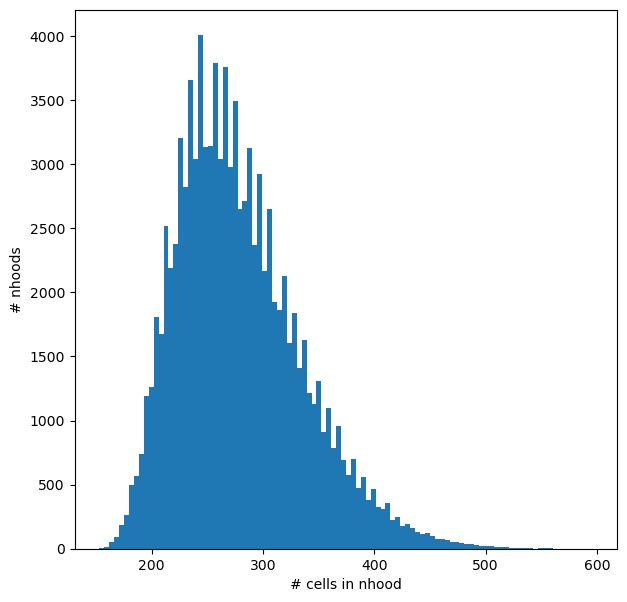

In [82]:
nhood_size = np.array(mdata["rna"].obsm["nhoods"].sum(0)).ravel()
plt.hist(nhood_size, bins=100)
plt.xlabel("# cells in nhood")
plt.ylabel("# nhoods")

# Count cells in neighborhoods

In [83]:
mdata = milo.count_nhoods(mdata, sample_col="sample_name")

In [84]:
mdata

MuData object with n_obs × n_vars = 1187341 × 2000
  2 modalities
    rna:	1187341 x 2000
      obs:	'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'slide_ID', 'sample_name', 'n_genes', 'slide_name', 'condition', 'donor', 'run', 'modulator', 'age', 'mutation', 'sex', '_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'leiden_resolvi_0.1', 'leiden_resolvi_0.2', 'leiden_resolvi_0.3', 'leiden_resolvi_0.4', 'leiden_resolvi_0.5', 'leiden_resolvi_0.6', 'leiden_resolvi_0.7', 'leiden_resolvi_0.8', 'leiden_resolvi_0.9', 'leiden_resolvi_1.0', 'leiden_resolvi_1.1', 'leiden_resolvi_1.2', 'leiden_resolvi_1.3', 'leiden_resolvi_1.4', 'leiden_resolvi_1.5', 'ct_resolvi', 'ann_lvl_3', 'airway-epithelium_leiden_n10_0.4', 'ann_lvl_3_refined', 'ambiguous_leiden_n10_0.2', 'plasma_leiden_n10_0.3', 'T_leiden_n10_0.3', 'B_leiden_n10_0.2', 'endothelial_leiden_n10_0.2', 'ann_lvl_2', 'ann_lvl_1', 'niches_k_1', 'niches_k_2', 'niches_k_3', 'niches_k_4', 'niches_k_5', 'niches_k_6', 'niches_k_7', 'niches_k_8', 'niches_k_9', 'niches_k_10', 'niches_k_11', 'niche_name', 'cluster_cellcharter_k2', 'cluster_cellcharter_k3', 'cluster_cellcharter_k4', 'cluster_cellcharter_k5', 'cluster_cellcharter_k6', 'cluster_cellcharter_k7', 'cluster_cellcharter_k8', 'cluster_cellcharter_k9', 'cluster_cellcharter_k10', 'cluster_cellcharter', 'kmeans_niche', 'cellcharter_niche', 'kmeans_niches', 'cellcharter_niches', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
      var:	'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
      uns:	'_scvi_manager_uuid', '_scvi_uuid', 'ann_lvl_1_colors', 'ann_lvl_2_colors', 'ann_lvl_3_colors', 'ann_lvl_3_refined_colors', 'cellcharter_niches_colors', 'donor_colors', 'hvg', 'kmeans_niches_colors', 'leiden_resolvi', 'leiden_resolvi_1.0_colors', 'log1p', 'nb_resolvi', 'nb_unint', 'neighbors', 'nhood_neighbors_key', 'niche_name_colors', 'pca', 'run_colors', 'sample_name_colors', 'slide_name_colors', 'spatial_neighbors', 'umap_resolvi', 'umap_unint'
      obsm:	'X_cellcharter', 'X_pca', 'X_resolvi', 'X_spatial', 'X_spatial_offset', 'X_umap', '_scvi_extra_categorical_covs', 'distance_neighbor', 'index_neighbor', 'nhoods', 'spatial', 'umap_resolvi', 'umap_unint'
      varm:	'PCs'
      layers:	'counts', 'resolvi_normalized'
      obsp:	'connectivities', 'distances', 'nb_resolvi_connectivities', 'nb_resolvi_distances', 'nb_unint_connectivities', 'nb_unint_distances', 'spatial_connectivities', 'spatial_distances'
    milo:	12 x 100843
      var:	'index_cell', 'kth_distance'
      uns:	'sample_col'

In [85]:
mdata['milo']

AnnData object with n_obs × n_vars = 12 × 100843
    var: 'index_cell', 'kth_distance'
    uns: 'sample_col'

# Differential Abundance testing

## CF vs CTRL

In [86]:
# Reorder categories (by default, the last category is taken as the condition of interest)
mdata["rna"].obs["condition"] = mdata["rna"].obs["condition"].cat.reorder_categories(["CTRL", "CF_ETI", "CF"])


In [87]:
# taking run+condition into account
milo.da_nhoods(
    mdata,
    design="~run+condition",
    model_contrasts="conditionCF-conditionCTRL",
    solver="pydeseq2",
)

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.07 seconds.

Fitting dispersions...
... done in 7.07 seconds.

Fitting dispersion trend curve...
/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 1.54 seconds.

Fitting MAP dispersions...
... done in 7.54 seconds.

Fitting LFCs...
... done in 7.82 seconds.

Calculating cook's distance...
... done in 0.03 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 5.95 seconds.



Log2 fold change & Wald test p-value: condition CF vs CTRL
         baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
0       15.026038        2.147251  1.445472  1.485502  0.137411  0.243520
1       10.231934        5.150153  1.590302  3.238475  0.001202  0.016028
2       15.199116       -0.833792  0.928127 -0.898359  0.368994  0.496944
3       12.252306        2.167237  1.157356  1.872576  0.061127  0.137910
4       12.196332        2.273100  1.332544  1.705835  0.088039  0.177576
...           ...             ...       ...       ...       ...       ...
100838  19.632997       -2.243884  1.072042 -2.093093  0.036341  0.097115
100839  12.964080        2.989774  1.378819  2.168359  0.030131  0.085986
100840  19.154540        1.637003  1.436237  1.139786  0.254376  0.379019
100841  12.756474        5.010555  1.697899  2.951033  0.003167  0.024717
100842  20.313159       -2.377742  1.159525 -2.050617  0.040304  0.104009

[100843 rows x 6 columns]


In [88]:
mdata["milo"].obs

,condition,run,sample_name
CTRL01,CTRL,RUN03,CTRL01
CTRL02,CTRL,RUN03,CTRL02
CTRL03,CTRL,RUN03,CTRL03
CTRL04,CTRL,RUN03,CTRL04
CTRL05,CTRL,RUN03,CTRL05
PWCF01_1,CF,RUN01,PWCF01_1
PWCF01_2,CF,RUN01,PWCF01_2
PWCF02,CF,RUN02,PWCF02
PWCF03,CF,RUN02,PWCF03
PWCF04,CF_ETI,RUN02,PWCF04


In [89]:
mdata["milo"].var

,index_cell,kth_distance,logCPM,logFC,PValue,FDR,SpatialFDR
0,SLIDE04_26,2.343445,15.026038,2.147251,0.137411,0.243520,0.247985
1,SLIDE04_30,2.710098,10.231934,5.150153,0.001202,0.016028,0.016590
2,SLIDE04_48,2.997407,15.199116,-0.833792,0.368994,0.496944,0.501960
3,SLIDE04_58,2.401934,12.252306,2.167237,0.061127,0.137910,0.141107
4,SLIDE04_67,3.121565,12.196332,2.273100,0.088039,0.177576,0.181323
...,...,...,...,...,...,...,...
100838,SLIDE02_426884,3.764919,19.632997,-2.243884,0.036341,0.097115,0.099567
100839,SLIDE02_426893,2.510262,12.964080,2.989774,0.030131,0.085986,0.088198
100840,SLIDE02_426908,2.467301,19.154540,1.637003,0.254376,0.379019,0.384211
100841,SLIDE02_426925,2.449744,12.756474,5.010555,0.003167,0.024717,0.025417


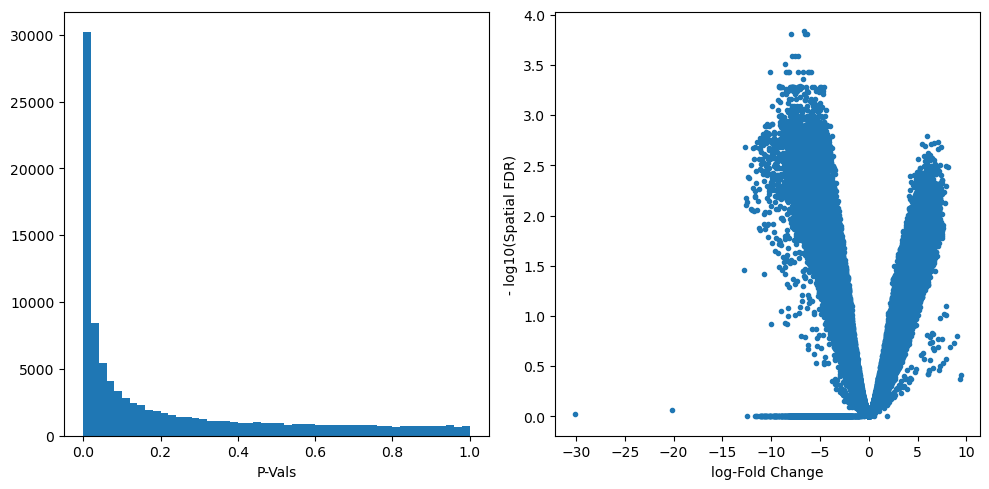

In [90]:
old_figsize = plt.rcParams["figure.figsize"]
plt.rcParams["figure.figsize"] = [10, 5]
plt.subplot(1, 2, 1)
plt.hist(mdata["milo"].var.PValue, bins=50)
plt.xlabel("P-Vals")
plt.subplot(1, 2, 2)
plt.plot(mdata["milo"].var.logFC, -np.log10(mdata["milo"].var.SpatialFDR), ".")
plt.xlabel("log-Fold Change")
plt.ylabel("- log10(Spatial FDR)")
plt.tight_layout()
plt.rcParams["figure.figsize"] = old_figsize

In [91]:
milo.build_nhood_graph(mdata)

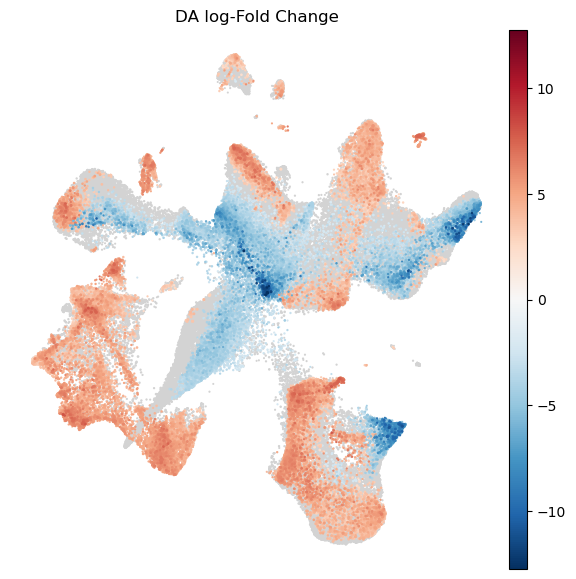

In [92]:
plt.rcParams["figure.figsize"] = [7, 7]
milo.plot_nhood_graph(
    mdata,
    padj_threshold=0.1,  # SpatialFDR level (1%)
    min_size=0.05,  # Size of smallest dot
)

### Visualize result by CELL TYPE

In [60]:
milo.annotate_nhoods(mdata, anno_col="ann_lvl_3_refined")

Text(0.5, 0, 'celltype fraction')

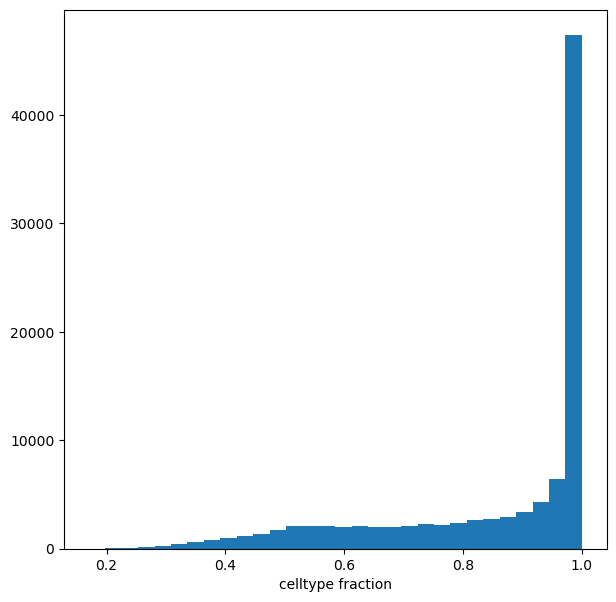

In [61]:
plt.hist(mdata["milo"].var["nhood_annotation_frac"], bins=30)
plt.xlabel("celltype fraction")

In [62]:
for cutoff in [0.5, 0.6, 0.7, 0.8, 0.9]:
    frac_mixed = (
        mdata["milo"].var["nhood_annotation_frac"] < cutoff
    ).mean()

    print(cutoff, frac_mixed)

0.5 0.07384673356868034
0.6 0.1489627543532585
0.7 0.22219467692673833
0.8 0.3023184324302884
0.9 0.4024830431161001


In [63]:
mdata["milo"].var["nhood_annotation"] = mdata["milo"].var["nhood_annotation"].cat.add_categories("Mixed")
mdata["milo"].var.loc[mdata["milo"].var["nhood_annotation_frac"] < 0.6, "nhood_annotation"] = "Mixed"

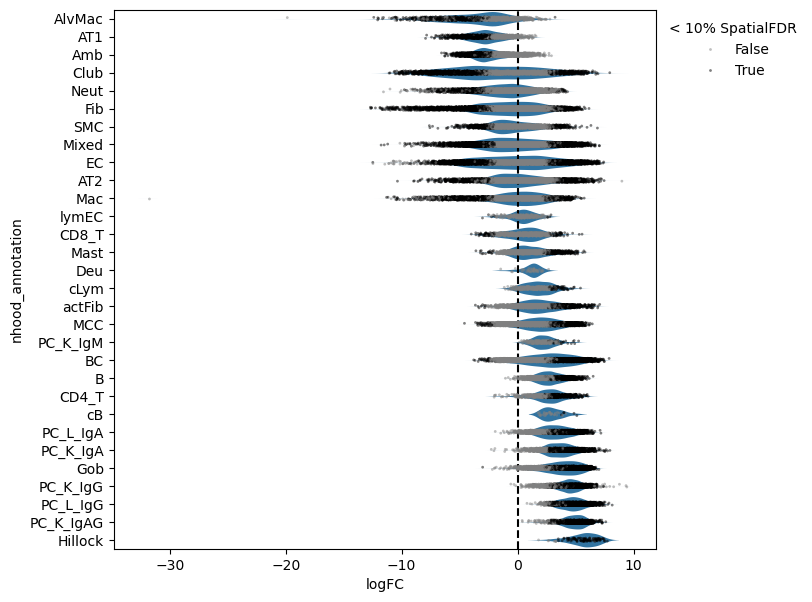

In [64]:
milo.plot_da_beeswarm(mdata, padj_threshold=0.1)

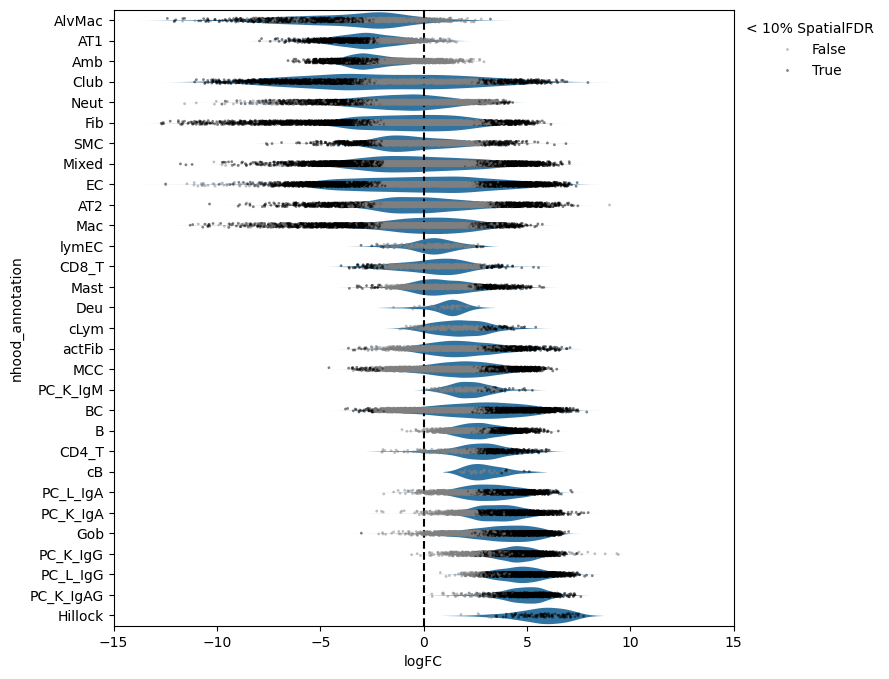

In [65]:
fig = milo.plot_da_beeswarm(
    mdata,
    padj_threshold=0.1,
    return_fig=True
)

fig.set_size_inches(8, 8)

# Limit logFC axis
ax = fig.axes[0]
ax.set_xlim(-15, 15)

out_dir = Path(
    "/mnt/data/project0062/proseg_data/results/comb/da_ct"
)
out_dir.mkdir(parents=True, exist_ok=True)

for ext in ["png", "svg"]:
    fig.savefig(
        out_dir / f"milo_beeswarm_CF_vs_CTRL.{ext}",
        dpi=900,
        bbox_inches="tight"
    )

In [66]:
milo_res = mdata["milo"].var

milo_res.sort_values("logFC").head(20)[
    ["nhood_annotation", "logFC", "SpatialFDR"]
]

,nhood_annotation,logFC,SpatialFDR
87281,Mac,-31.749081,0.894702
88269,AlvMac,-19.862071,0.793360
44273,Fib,-12.700203,0.034234
88189,Fib,-12.661769,0.002095
40484,Fib,-12.604520,0.006694
39356,Fib,-12.587345,0.007770
43658,EC,-12.488031,0.007241
44325,EC,-12.477871,1.000000
29246,AlvMac,-12.403676,0.004151
88470,Fib,-12.262706,0.004258


In [67]:
import pandas as pd
import numpy as np

res = mdata["milo"].var.copy()

# Significant DA neighbourhoods
sig = res[res["SpatialFDR"] < 0.1].copy()

# Direction using an absolute logFC threshold of 0

fold_thres = 0
sig["direction"] = np.select(
    [
        sig["logFC"] >= fold_thres,
        sig["logFC"] <= -fold_thres,
    ],
    [
        "Enriched in CF",
        "Depleted in CF",
    ],
    default="No strong change"
)

# Keep only significant neighbourhoods with |logFC| >= 1
sig_strong = sig[sig["logFC"].abs() >= 1].copy()

# Count significant + strong neighbourhoods in each direction
direction_counts = pd.crosstab(
    sig_strong["nhood_annotation"],
    sig_strong["direction"]
).reindex(
    columns=["Enriched in CF", "Depleted in CF"],
    fill_value=0
)

# Total number of neighbourhoods per cell type
total = (
    res.groupby("nhood_annotation", observed=True)
    .size()
    .rename("n_nhoods")
)

# Median logFC among significant + strong neighbourhoods
median_lfc = (
    sig_strong
    .groupby("nhood_annotation", observed=True)["logFC"]
    .median()
    .rename("median_logFC_sig")
)

# Combine, starting from total so all cell types are retained
summary = (
    total.to_frame()
    .join(direction_counts)
    .join(median_lfc)
)

# Cell types with no significant |logFC| >= 1 neighbourhoods
summary[["Enriched in CF", "Depleted in CF"]] = (
    summary[["Enriched in CF", "Depleted in CF"]]
    .fillna(0)
    .astype(int)
)

# Number of significant + strong neighbourhoods
summary["n_sig"] = (
    summary["Enriched in CF"] +
    summary["Depleted in CF"]
)

# Percentage of all neighbourhoods that are significant + strong
summary["pct_sig"] = (
    summary["n_sig"] /
    summary["n_nhoods"] * 100
)

# Overall direction for each cell type
summary["DA_direction"] = np.select(
    [
        summary["Enriched in CF"] > summary["Depleted in CF"],
        summary["Depleted in CF"] > summary["Enriched in CF"],
    ],
    [
        "Enriched in CF",
        "Depleted in CF",
    ],
    default="Mixed / no DA"
)

# Final table
summary_out = summary[
    [
        "n_nhoods",
        "n_sig",
        "pct_sig",
        "Enriched in CF",
        "Depleted in CF",
        "median_logFC_sig",
        "DA_direction",
    ]
].round(2)

# Order direction
summary_out["DA_direction"] = pd.Categorical(
    summary_out["DA_direction"],
    categories=[
        "Enriched in CF",
        "Depleted in CF",
        "Mixed / no DA",
    ],
    ordered=True,
)

# Group by direction, then strongest evidence within each group
summary_out = summary_out.sort_values(
    ["DA_direction", "pct_sig"],
    ascending=[True, False],
)

summary_out

,n_nhoods,n_sig,pct_sig,Enriched in CF,Depleted in CF,median_logFC_sig,DA_direction
nhood_annotation,,,,,,,
Hillock,106,96,90.57,96,0,5.82,Enriched in CF
PC_L_IgG,1961,1763,89.90,1763,0,4.81,Enriched in CF
PC_K_IgAG,1058,947,89.51,947,0,5.00,Enriched in CF
PC_K_IgG,4166,3359,80.63,3359,0,4.64,Enriched in CF
PC_K_IgA,3219,2004,62.26,2004,0,4.21,Enriched in CF
Gob,2863,1625,56.76,1624,1,4.80,Enriched in CF
CD4_T,624,327,52.40,327,0,3.47,Enriched in CF
PC_L_IgA,3057,1444,47.24,1444,0,4.14,Enriched in CF
BC,4684,2208,47.14,2170,38,4.25,Enriched in CF


####### PC_K_IgA #######


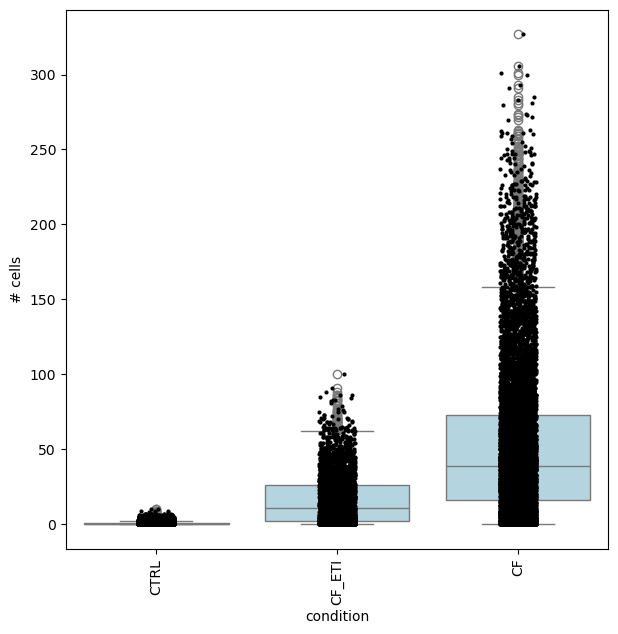

####### Fib #######


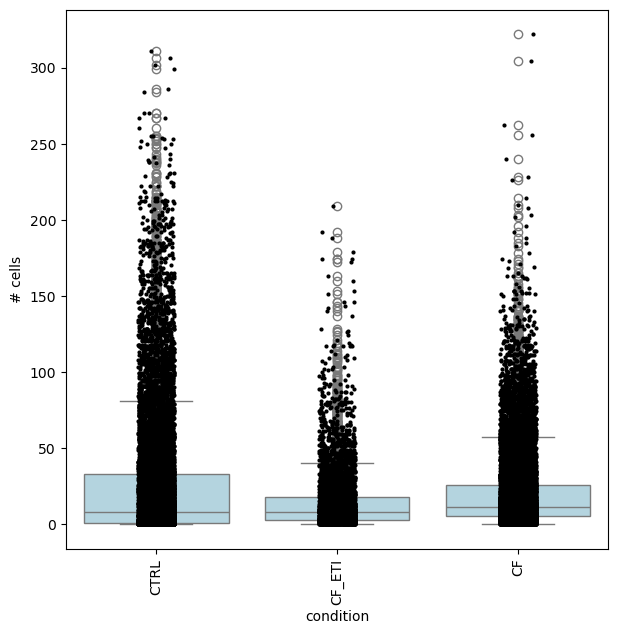

####### Neut #######


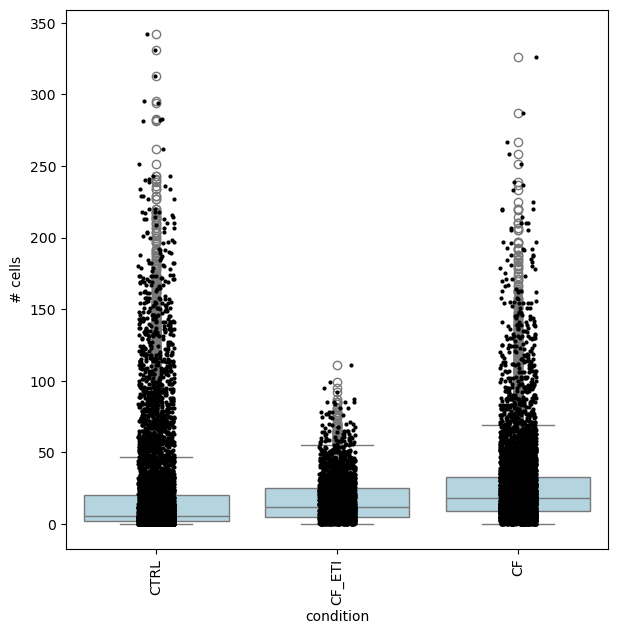

####### CD8_T #######


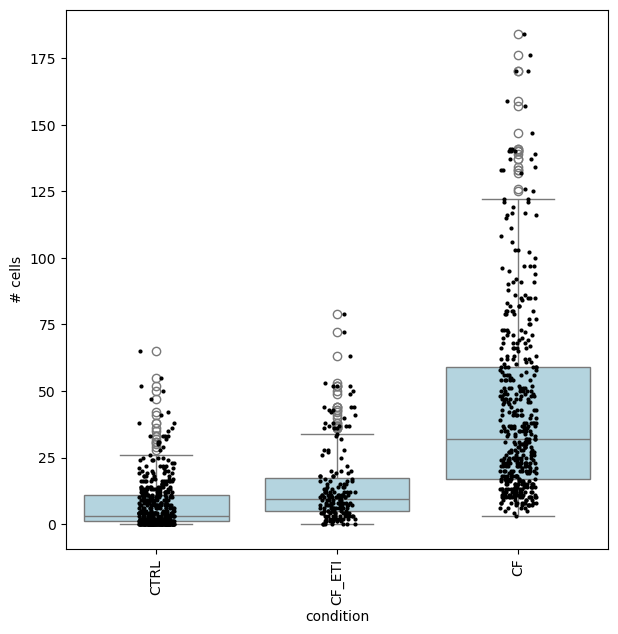

####### SMC #######


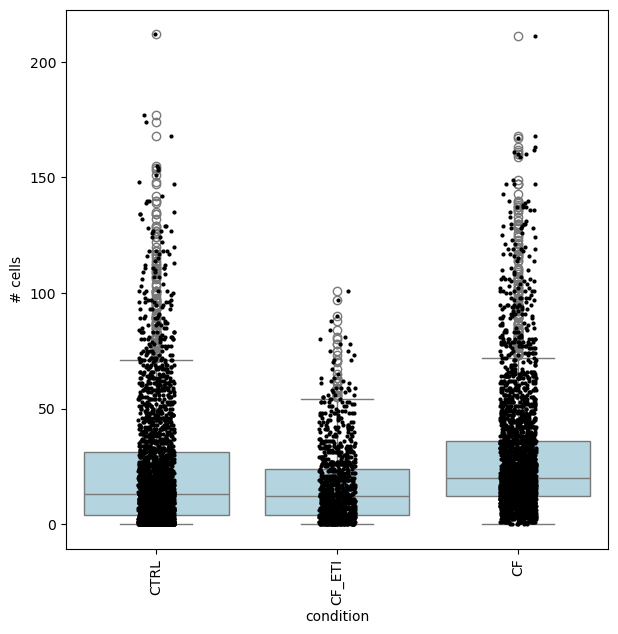

####### EC #######


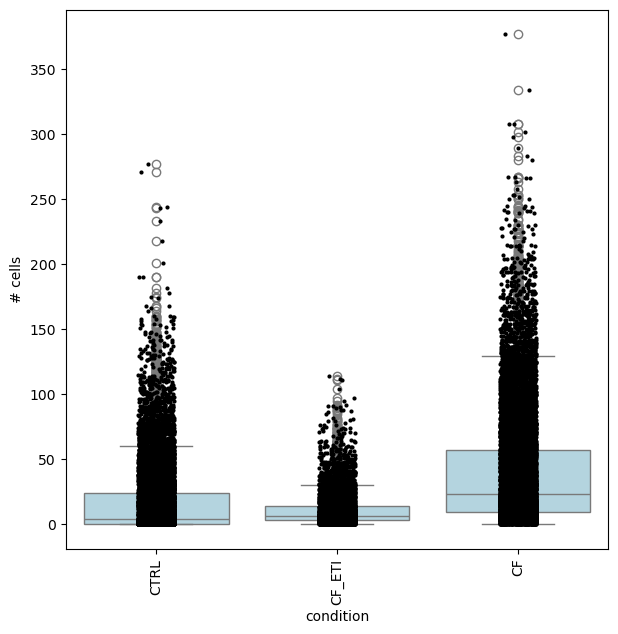

####### Amb #######


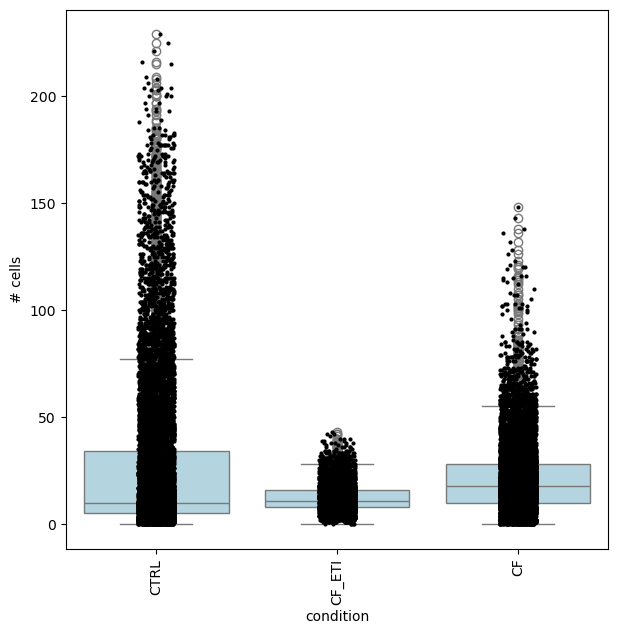

####### Mac #######


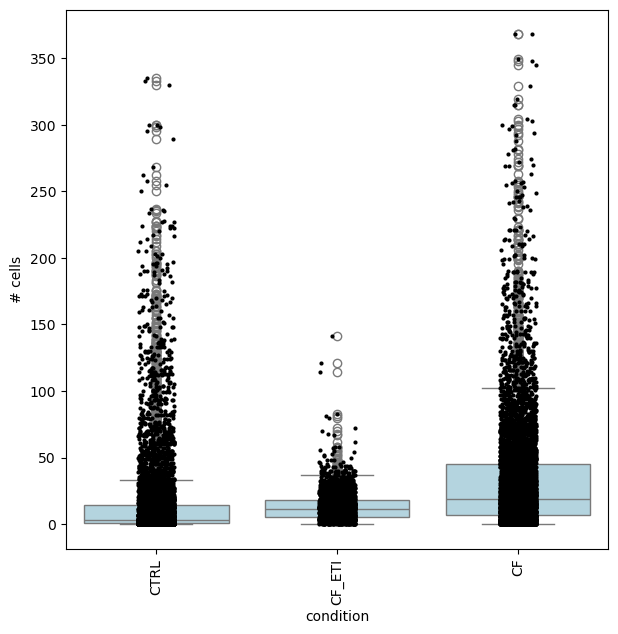

####### PC_L_IgA #######


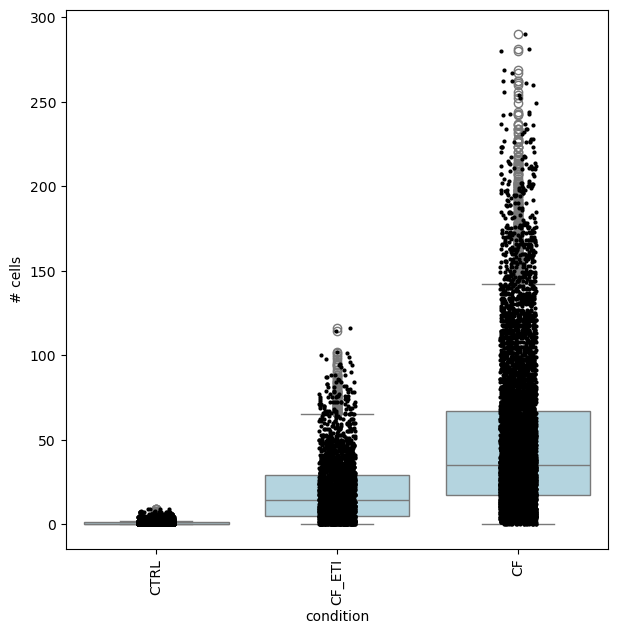

####### PC_L_IgG #######


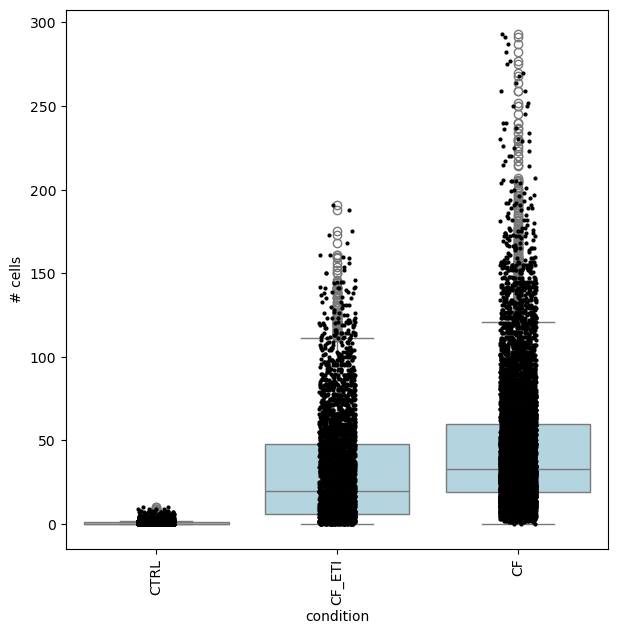

####### PC_K_IgAG #######


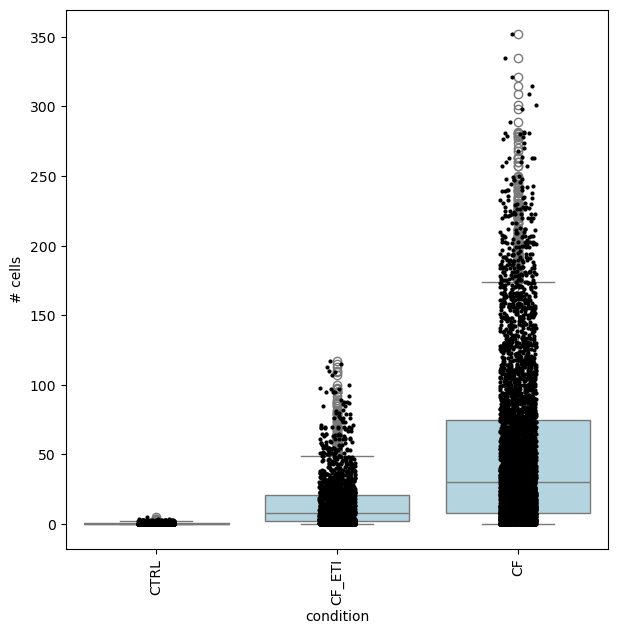

####### Mast #######


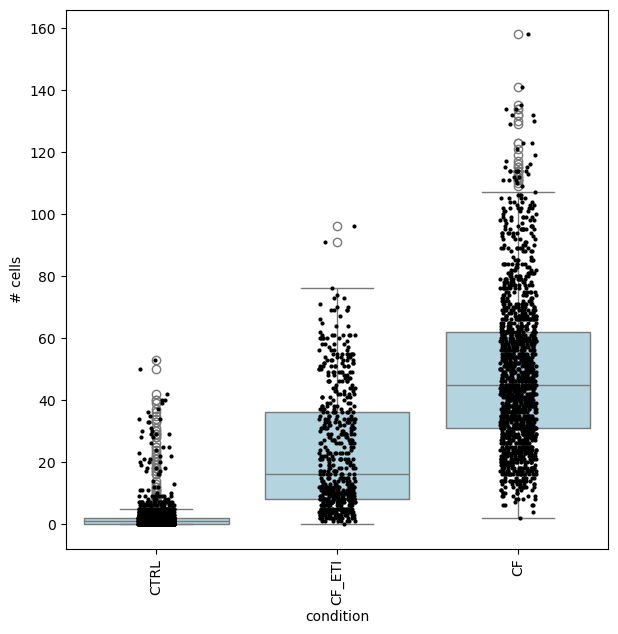

####### actFib #######


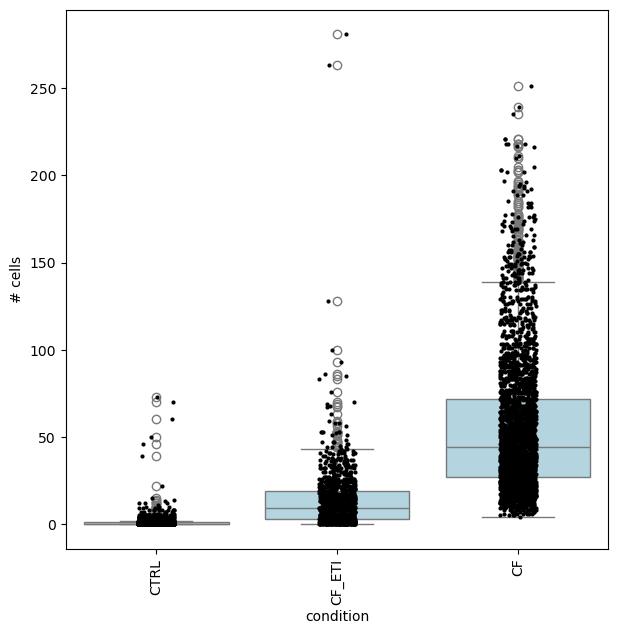

####### AT2 #######


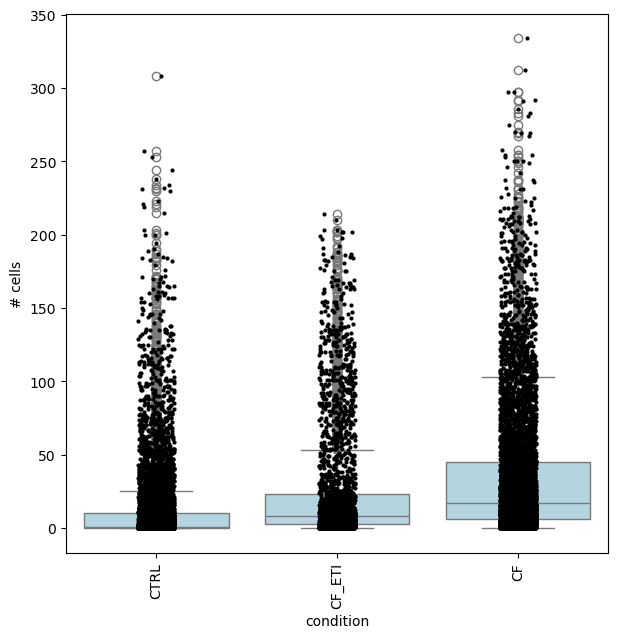

####### CD4_T #######


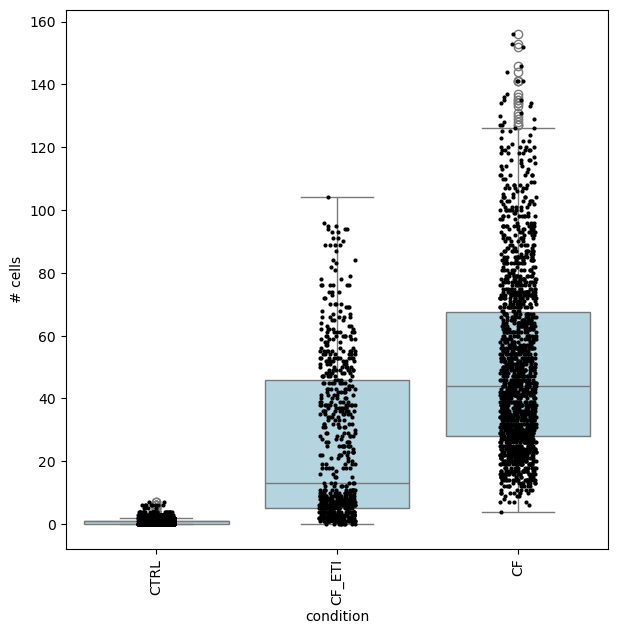

####### cLym #######


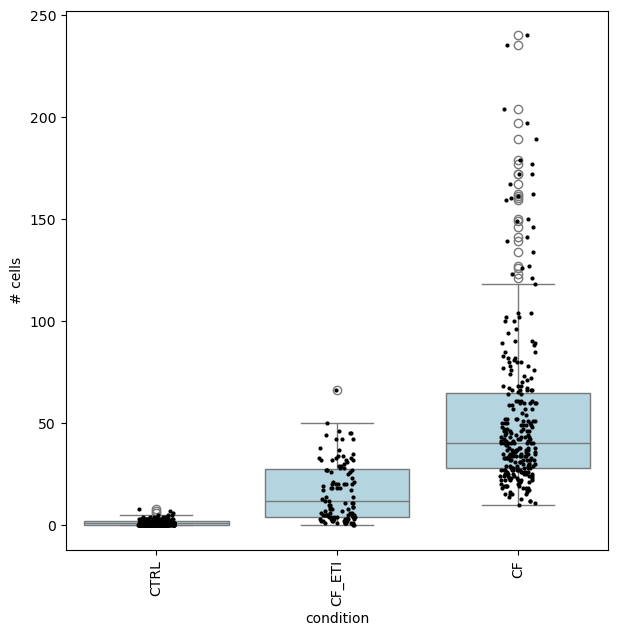

####### AlvMac #######


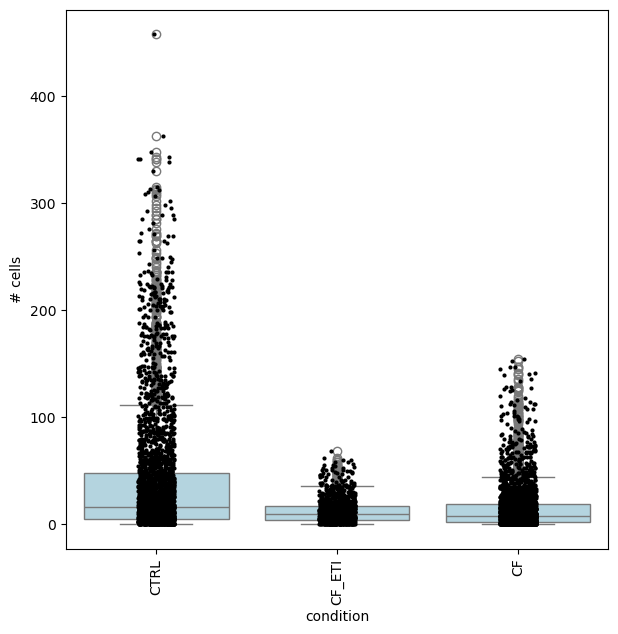

####### BC #######


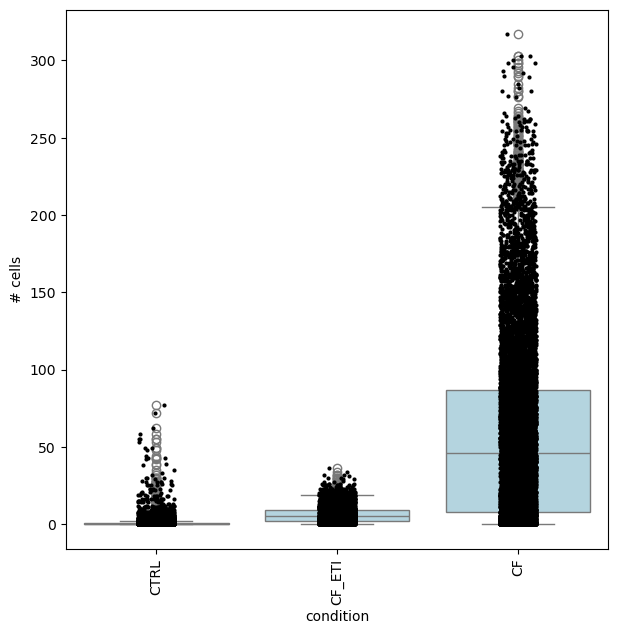

####### AT1 #######


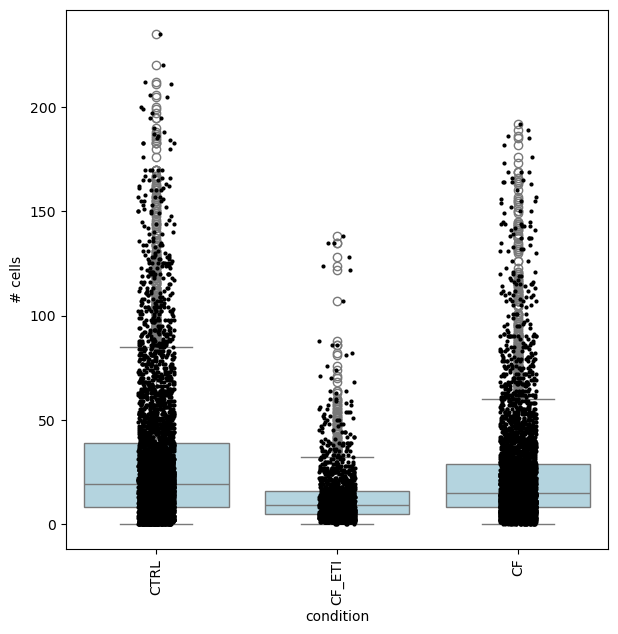

####### PC_K_IgG #######


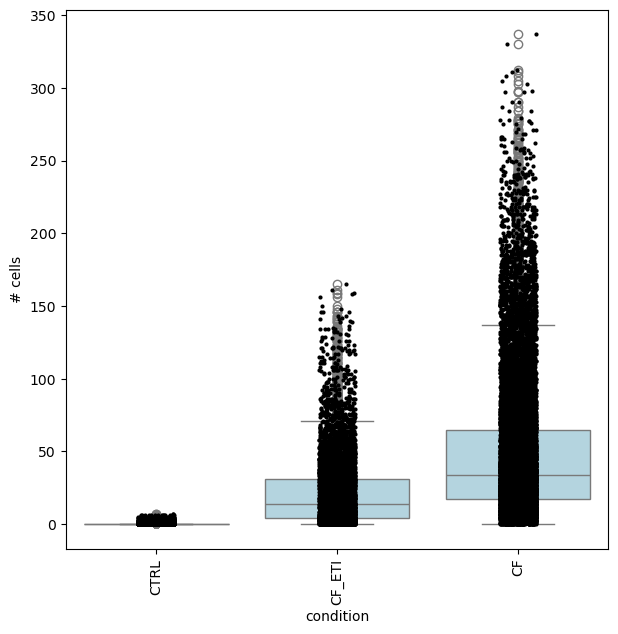

####### B #######


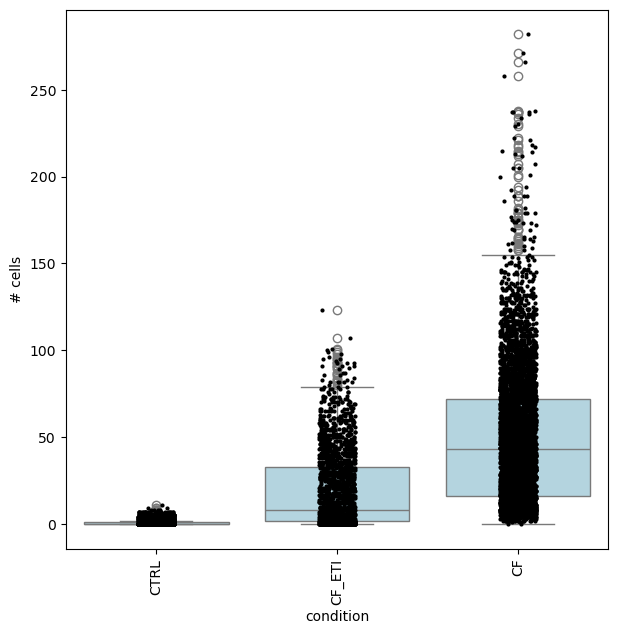

####### lymEC #######


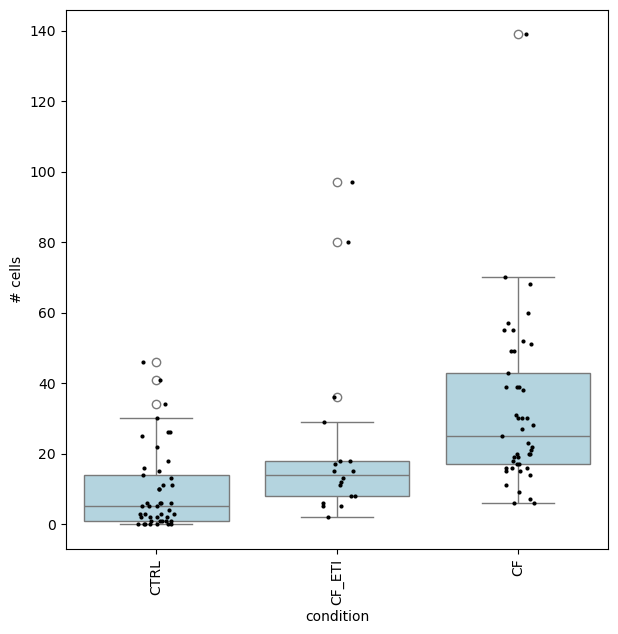

####### PC_K_IgM #######


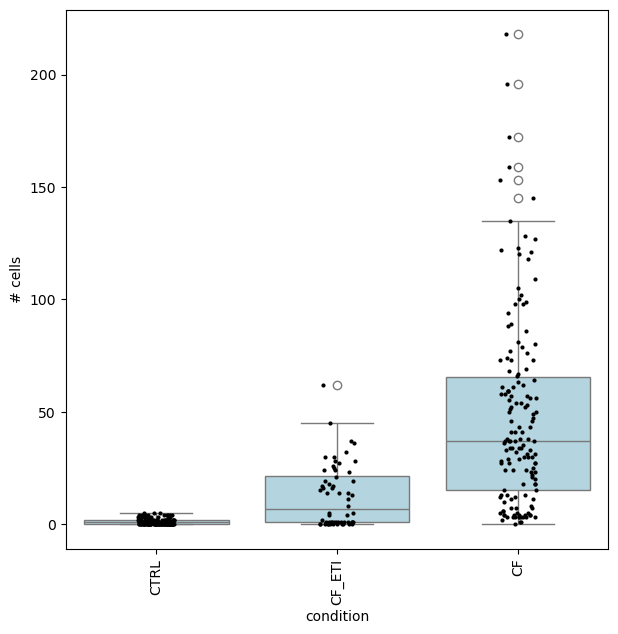

####### Club #######


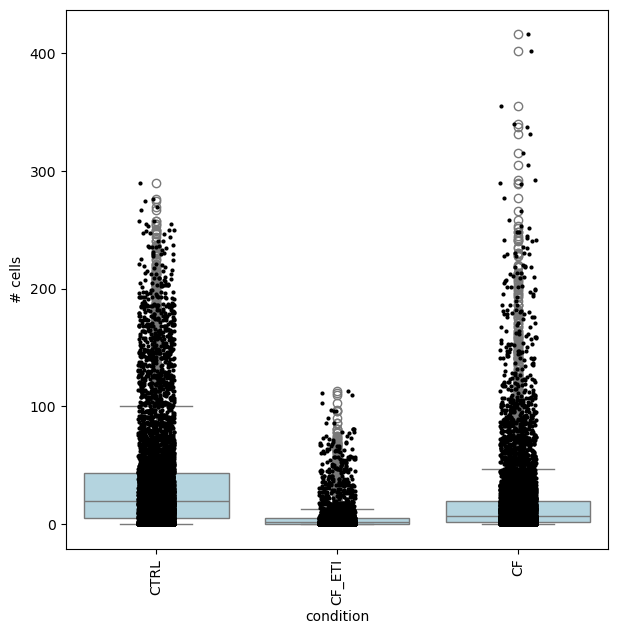

####### Gob #######


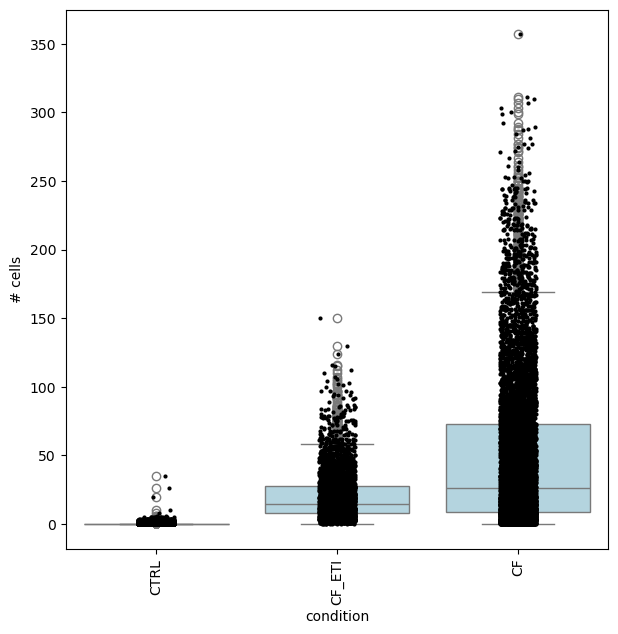

####### MCC #######


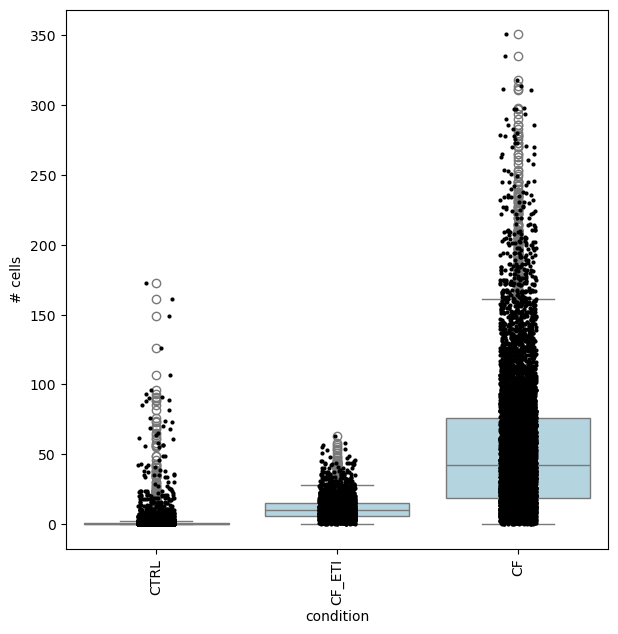

####### cB #######


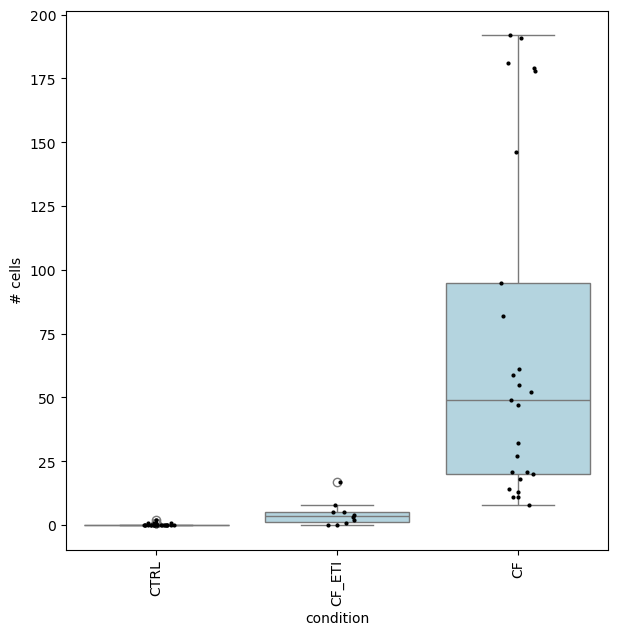

####### Hillock #######


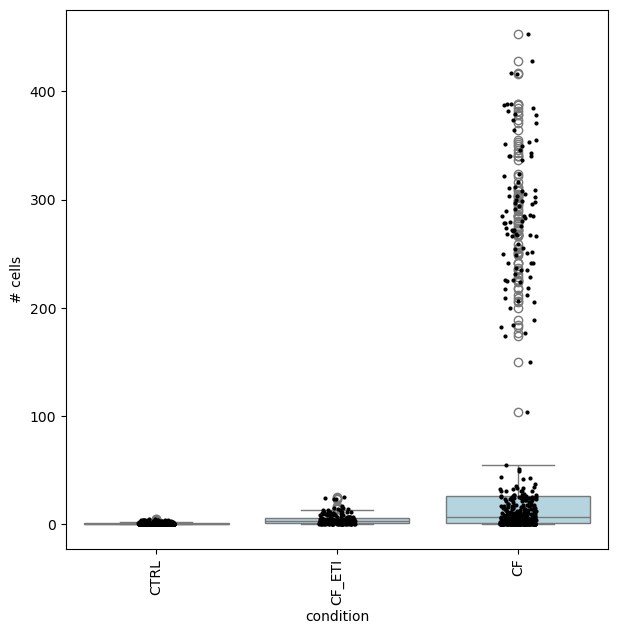

####### Deu #######


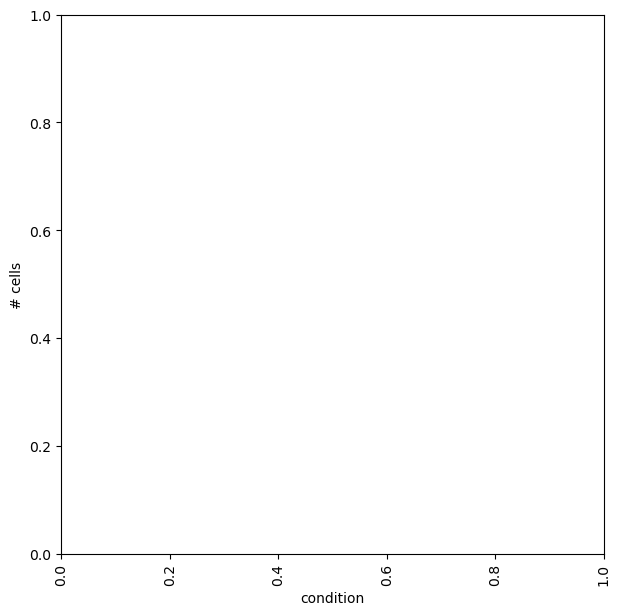

In [69]:
celltypes = mdata['rna'].obs['ann_lvl_3_refined'].unique().tolist()

for ct in celltypes:

    pl_nhoods = mdata["milo"].var_names[
        (mdata["milo"].var["SpatialFDR"] < 0.1) & (mdata["milo"].var["nhood_annotation"] == ct)
    ]
    
    ## Visualize cell counts by condition (x-axis) and individuals on all neighbourhoods
    print(f'####### {ct} #######')
    milo.plot_nhood_counts_by_cond(mdata, test_var="condition", subset_nhoods=pl_nhoods, log_counts=False)

In [70]:
import pandas as pd
import numpy as np

res = mdata["milo"].var.copy()

# Significant DA neighbourhoods
sig = res[res["SpatialFDR"] < 0.1].copy()

# Direction using an absolute logFC threshold of 0

fold_thres = 0
sig["direction"] = np.select(
    [
        sig["logFC"] >= fold_thres,
        sig["logFC"] <= -fold_thres,
    ],
    [
        "Enriched in CF",
        "Depleted in CF",
    ],
    default="No strong change"
)

# Count significant + strong neighbourhoods in each direction
direction_counts = pd.crosstab(
    sig_strong["nhood_annotation"],
    sig_strong["direction"]
).reindex(
    columns=["Enriched in CF", "Depleted in CF"],
    fill_value=0
)

# Total number of neighbourhoods per cell type
total = (
    res.groupby("nhood_annotation", observed=True)
    .size()
    .rename("n_nhoods")
)

# Median logFC among significant + strong neighbourhoods
median_lfc = (
    sig_strong
    .groupby("nhood_annotation", observed=True)["logFC"]
    .median()
    .rename("median_logFC_sig")
)

# Combine, starting from total so all cell types are retained
summary = (
    total.to_frame()
    .join(direction_counts)
    .join(median_lfc)
)

# Cell types with no significant |logFC| >= 1 neighbourhoods
summary[["Enriched in CF", "Depleted in CF"]] = (
    summary[["Enriched in CF", "Depleted in CF"]]
    .fillna(0)
    .astype(int)
)

# Number of significant + strong neighbourhoods
summary["n_sig"] = (
    summary["Enriched in CF"] +
    summary["Depleted in CF"]
)

# Percentage of all neighbourhoods that are significant + strong
summary["pct_sig"] = (
    summary["n_sig"] /
    summary["n_nhoods"] * 100
)

# Overall direction for each cell type
summary["DA_direction"] = np.select(
    [
        summary["Enriched in CF"] > summary["Depleted in CF"],
        summary["Depleted in CF"] > summary["Enriched in CF"],
    ],
    [
        "Enriched in CF",
        "Depleted in CF",
    ],
    default="Mixed / no DA"
)

# Final table
summary_out = summary[
    [
        "n_nhoods",
        "n_sig",
        "pct_sig",
        "Enriched in CF",
        "Depleted in CF",
        "median_logFC_sig",
        "DA_direction",
    ]
].round(2)

# Order direction
summary_out["DA_direction"] = pd.Categorical(
    summary_out["DA_direction"],
    categories=[
        "Enriched in CF",
        "Depleted in CF",
        "Mixed / no DA",
    ],
    ordered=True,
)

# Group by direction, then strongest evidence within each group
summary_out = summary_out.sort_values(
    ["DA_direction", "pct_sig"],
    ascending=[True, False],
)

summary_out

,n_nhoods,n_sig,pct_sig,Enriched in CF,Depleted in CF,median_logFC_sig,DA_direction
nhood_annotation,,,,,,,
Hillock,106,96,90.57,96,0,5.82,Enriched in CF
PC_L_IgG,1961,1763,89.90,1763,0,4.81,Enriched in CF
PC_K_IgAG,1058,947,89.51,947,0,5.00,Enriched in CF
PC_K_IgG,4166,3359,80.63,3359,0,4.64,Enriched in CF
PC_K_IgA,3219,2004,62.26,2004,0,4.21,Enriched in CF
Gob,2863,1625,56.76,1624,1,4.80,Enriched in CF
CD4_T,624,327,52.40,327,0,3.47,Enriched in CF
PC_L_IgA,3057,1444,47.24,1444,0,4.14,Enriched in CF
BC,4684,2208,47.14,2170,38,4.25,Enriched in CF


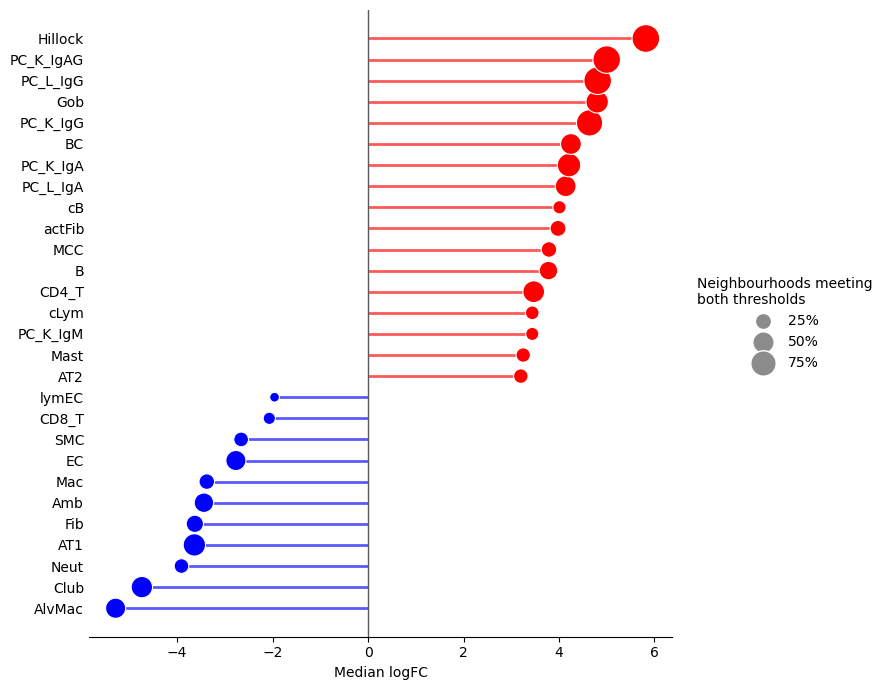

In [75]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = (
    summary_out
    .loc[summary_out.index != "Mixed"]
    .reset_index()
    .dropna(subset=["median_logFC_sig"])
    .sort_values("median_logFC_sig")
    .reset_index(drop=True)
)

y = np.arange(len(plot_df))
x = plot_df["median_logFC_sig"].to_numpy()

colors = np.where(
    x > 0,
    "red",  # red: higher in CF
    "blue",  # blue: lower in CF
)

fig, ax = plt.subplots(
    figsize=(9, 7)
)

ax.hlines(y, 0, x, color=colors, linewidth=2, alpha=0.65)

ax.scatter(
    x,
    y,
    s=35 + plot_df["pct_sig"].to_numpy() * 4,
    c=colors,
    edgecolor="white",
    linewidth=0.8,
    zorder=3,
)

ax.axvline(0, color="0.35", linewidth=1)
ax.set_yticks(y, plot_df["nhood_annotation"])
ax.set_xlabel("Median logFC")
ax.set_ylabel("")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)

for pct in [25, 50, 75]:
    ax.scatter(
        [], [], s=35 + pct * 4,
        color="0.55",
        edgecolor="white",
        label=f"{pct}%"
    )

ax.legend(
    title="Neighbourhoods meeting\nboth thresholds",
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
)

plt.tight_layout()
plt.show()

# Visualize result by NICHE

In [99]:
milo.annotate_nhoods(mdata, anno_col="cellcharter_niches")

Text(0.5, 0, 'celltype fraction')

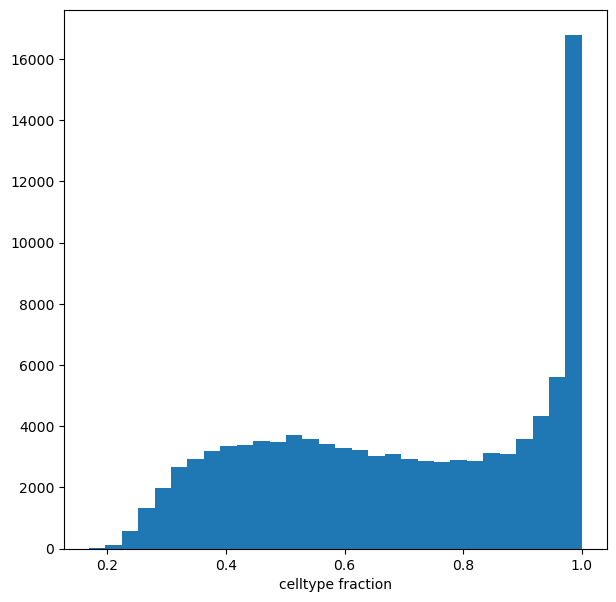

In [100]:
plt.hist(mdata["milo"].var["nhood_annotation_frac"], bins=30)
plt.xlabel("celltype fraction")

In [101]:
for cutoff in [0.5, 0.6, 0.7, 0.8, 0.9]:
    frac_mixed = (
        mdata["milo"].var["nhood_annotation_frac"] < cutoff
    ).mean()

    print(cutoff, frac_mixed)

0.5 0.26093035708973356
0.6 0.38798925061729617
0.7 0.49976696448935476
0.8 0.6025306664815604
0.9 0.7131481610027468


In [102]:
mdata["milo"].var["nhood_annotation"] = mdata["milo"].var["nhood_annotation"].cat.add_categories("Mixed")
mdata["milo"].var.loc[mdata["milo"].var["nhood_annotation_frac"] < 0.6, "nhood_annotation"] = "Mixed"

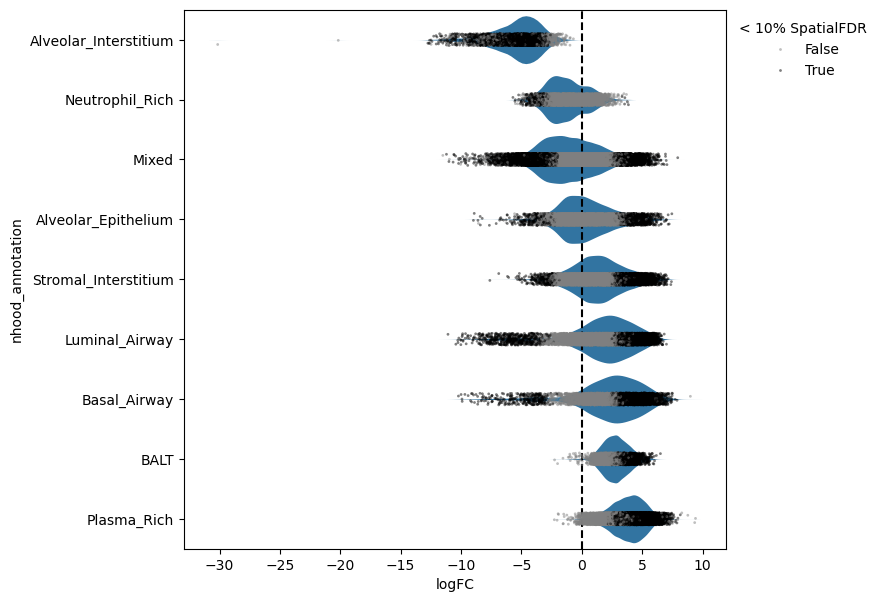

In [103]:
milo.plot_da_beeswarm(mdata, padj_threshold=0.1)

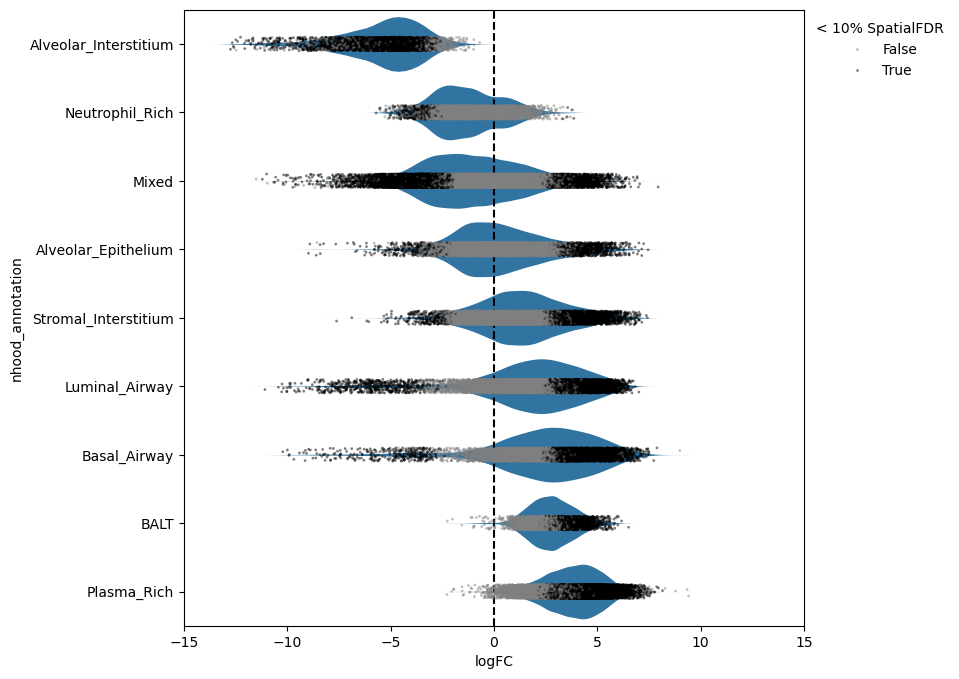

In [104]:
fig = milo.plot_da_beeswarm(
    mdata,
    padj_threshold=0.1,
    return_fig=True
)

fig.set_size_inches(8, 8)

# Limit logFC axis
ax = fig.axes[0]
ax.set_xlim(-15, 15)

out_dir = Path(
    "/mnt/data/project0062/proseg_data/results/comb/da_niche"
)
out_dir.mkdir(parents=True, exist_ok=True)

for ext in ["png", "svg"]:
    fig.savefig(
        out_dir / f"milo_beeswarm_CF_vs_CTRL.{ext}",
        dpi=900,
        bbox_inches="tight"
    )

In [111]:
direction_counts

direction,Enriched in CF,Depleted in CF
nhood_annotation,,
AT1,0,828
AT2,723,636
AlvMac,1,582
Amb,0,2350
B,1010,0
BC,2170,38
CD4_T,327,0
CD8_T,40,50
Club,249,1067


In [ ]:
import pandas as pd
import numpy as np

res = mdata["milo"].var.copy()

# Significant DA neighbourhoods
sig = res[res["SpatialFDR"] < 0.1].copy()

# Direction using an absolute logFC threshold of 0

fold_thres = 0
sig["direction"] = np.select(
    [
        sig["logFC"] >= fold_thres,
        sig["logFC"] <= -fold_thres,
    ],
    [
        "Enriched in CF",
        "Depleted in CF",
    ],
    default="No strong change"
)

# Count significant + strong neighbourhoods in each direction
direction_counts = pd.crosstab(
    sig_strong["nhood_annotation"],
    sig_strong["direction"]
).reindex(
    columns=["Enriched in CF", "Depleted in CF"],
    fill_value=0
)

# Total number of neighbourhoods per cell type
total = (
    res.groupby("nhood_annotation", observed=True)
    .size()
    .rename("n_nhoods")
)

# Median logFC among significant + strong neighbourhoods
median_lfc = (
    sig_strong
    .groupby("nhood_annotation", observed=True)["logFC"]
    .median()
    .rename("median_logFC_sig")
)

# Combine, starting from total so all cell types are retained
summary = (
    total.to_frame()
    .join(direction_counts)
    .join(median_lfc)
)

summary

In [106]:
import pandas as pd
import numpy as np

res = mdata["milo"].var.copy()

# Significant DA neighbourhoods
sig = res[res["SpatialFDR"] < 0.1].copy()

# Direction using an absolute logFC threshold of 0

fold_thres = 0
sig["direction"] = np.select(
    [
        sig["logFC"] >= fold_thres,
        sig["logFC"] <= -fold_thres,
    ],
    [
        "Enriched in CF",
        "Depleted in CF",
    ],
    default="No strong change"
)

# Count significant + strong neighbourhoods in each direction
direction_counts = pd.crosstab(
    sig_strong["nhood_annotation"],
    sig_strong["direction"]
).reindex(
    columns=["Enriched in CF", "Depleted in CF"],
    fill_value=0
)

# Total number of neighbourhoods per cell type
total = (
    res.groupby("nhood_annotation", observed=True)
    .size()
    .rename("n_nhoods")
)

# Median logFC among significant + strong neighbourhoods
median_lfc = (
    sig_strong
    .groupby("nhood_annotation", observed=True)["logFC"]
    .median()
    .rename("median_logFC_sig")
)

# Combine, starting from total so all cell types are retained
summary = (
    total.to_frame()
    .join(direction_counts)
    .join(median_lfc)
)

# Cell types with no significant |logFC| >= 1 neighbourhoods
summary[["Enriched in CF", "Depleted in CF"]] = (
    summary[["Enriched in CF", "Depleted in CF"]]
    .fillna(0)
    .astype(int)
)

# Number of significant + strong neighbourhoods
summary["n_sig"] = (
    summary["Enriched in CF"] +
    summary["Depleted in CF"]
)

# Percentage of all neighbourhoods that are significant + strong
summary["pct_sig"] = (
    summary["n_sig"] /
    summary["n_nhoods"] * 100
)

# Overall direction for each cell type
summary["DA_direction"] = np.select(
    [
        summary["Enriched in CF"] > summary["Depleted in CF"],
        summary["Depleted in CF"] > summary["Enriched in CF"],
    ],
    [
        "Enriched in CF",
        "Depleted in CF",
    ],
    default="Mixed / no DA"
)

# Final table
summary_out = summary[
    [
        "n_nhoods",
        "n_sig",
        "pct_sig",
        "Enriched in CF",
        "Depleted in CF",
        "median_logFC_sig",
        "DA_direction",
    ]
].round(2)

# Order direction
summary_out["DA_direction"] = pd.Categorical(
    summary_out["DA_direction"],
    categories=[
        "Enriched in CF",
        "Depleted in CF",
        "Mixed / no DA",
    ],
    ordered=True,
)

# Group by direction, then strongest evidence within each group
summary_out = summary_out.sort_values(
    ["DA_direction", "pct_sig"],
    ascending=[True, False],
)

summary_out

,n_nhoods,n_sig,pct_sig,Enriched in CF,Depleted in CF,median_logFC_sig,DA_direction
nhood_annotation,,,,,,,
Mixed,39126,5059,12.93,1659,3400,-2.83,Depleted in CF
Stromal_Interstitium,9335,0,0.00,0,0,NaN,Mixed / no DA
Plasma_Rich,15978,0,0.00,0,0,NaN,Mixed / no DA
Neutrophil_Rich,4896,0,0.00,0,0,NaN,Mixed / no DA
Basal_Airway,5544,0,0.00,0,0,NaN,Mixed / no DA
Alveolar_Epithelium,7982,0,0.00,0,0,NaN,Mixed / no DA
BALT,3424,0,0.00,0,0,NaN,Mixed / no DA
Luminal_Airway,10713,0,0.00,0,0,NaN,Mixed / no DA
Alveolar_Interstitium,3845,0,0.00,0,0,NaN,Mixed / no DA


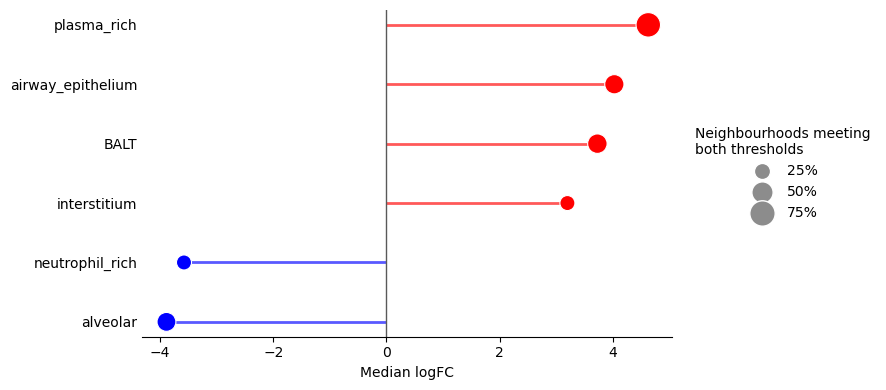

In [59]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = (
    summary_out
    .loc[summary_out.index != "Mixed"]
    .reset_index()
    .dropna(subset=["median_logFC_sig"])
    .sort_values("median_logFC_sig")
    .reset_index(drop=True)
)

y = np.arange(len(plot_df))
x = plot_df["median_logFC_sig"].to_numpy()

colors = np.where(
    x > 0,
    "red",  # red: higher in CF
    "blue",  # blue: lower in CF
)

fig, ax = plt.subplots(
    figsize=(9, max(4, 0.38 * len(plot_df)))
)

ax.hlines(y, 0, x, color=colors, linewidth=2, alpha=0.65)

ax.scatter(
    x,
    y,
    s=35 + plot_df["pct_sig"].to_numpy() * 4,
    c=colors,
    edgecolor="white",
    linewidth=0.8,
    zorder=3,
)

ax.axvline(0, color="0.35", linewidth=1)
ax.set_yticks(y, plot_df["nhood_annotation"])
ax.set_xlabel("Median logFC")
ax.set_ylabel("")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)

for pct in [25, 50, 75]:
    ax.scatter(
        [], [], s=35 + pct * 4,
        color="0.55",
        edgecolor="white",
        label=f"{pct}%"
    )

ax.legend(
    title="Neighbourhoods meeting\nboth thresholds",
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
)

plt.tight_layout()
plt.show()